In [7]:
import pandas as pd

In [8]:
df = pd.read_csv('result/results.csv')

In [9]:
df

,Unnamed: 0,threshold_0.5 (1),threshold_0.95 (1),threshold_0.5 (2),threshold_0.95 (2),threshold_0.5 (3),threshold_0.95 (3),threshold_0.5 (4),threshold_0.95 (4),threshold_0.5 (5),...,threshold_0.5 (all),threshold_0.95 (all),name,mAP (all),mAP (seg),mAP (text),mAP (title),mAP (list),mAP (table),mAP (figure)
0,0,0.519098,0.484429,0.461010,0.459130,0.431045,0.384709,0.691667,0.688333,0.485833,...,0.764516,0.689591,size_times_0.25,0.153439,0.520584,0.376262,0.177422,0.027009,0.016082,0.170422
1,1,0.650247,0.622753,0.579652,0.574235,0.490915,0.445977,0.755952,0.720952,0.577000,...,0.787963,0.719135,size_times_0.5,0.244810,0.559772,0.522487,0.258000,0.033002,0.129861,0.280699
2,2,0.650413,0.620059,0.622597,0.616962,0.462785,0.425446,0.687000,0.687000,0.520667,...,0.793413,0.728721,size_times_1,0.211161,0.568559,0.501910,0.257798,0.052857,0.023102,0.220137
3,3,0.624839,0.602103,0.599233,0.594233,0.510442,0.472536,0.702500,0.697500,0.533333,...,0.796721,0.734328,size_times_2,0.231020,0.597706,0.494353,0.294029,0.065158,0.061316,0.240244
4,4,0.554435,0.540012,0.663457,0.663457,0.323680,0.292704,0.777667,0.724000,0.578167,...,0.791536,0.741390,size_times_4,0.229784,0.584069,0.390375,0.292099,0.026262,0.151708,0.288474


In [10]:
st_df = df[['threshold_0.5 (all)', 'threshold_0.95 (all)','mAP (all)', 'mAP (seg)']]

In [11]:
st_df.describe().loc[['mean', 'std', 'max']]

,threshold_0.5 (all),threshold_0.95 (all),mAP (all),mAP (seg)
mean,0.786830,0.722633,0.214043,0.566138
std,0.012870,0.020185,0.035929,0.029324
max,0.796721,0.741390,0.244810,0.597706


In [16]:
import pandas as pd
import json
from pathlib import Path

def get_table(name):
    table = []
    for coef in [0.125, 0.25, 0.5, 1, 2, 4]:
        table_mini =  []
        for ed in [1, 2, 3]:
            
            name_res = f'{name}/row2region_GLAM_size_times_{coef}_no{ed}'
            name_save = Path(name_res+'_res.txt')
            if name_save.exists():
                with open(name_save, 'r') as f:
                    res = json.load(f)
            else:
               break 
            table_mini.append(res)
        if len(table_mini) == 0:
            break
        table_mini = pd.DataFrame(table_mini)
        res = table_mini[['threshold_0.5 (all)', 'threshold_0.95 (all)','mAP (all)', 'mAP (seg)']].describe()
        res = res.loc[['mean']]
        res['coef'] = coef
        table.append(res.copy())
    tbl = pd.concat(table)
    tbl=tbl.set_index('coef')
    return tbl

In [19]:
tbl1 = get_table('result_1k')
tbl2 = get_table('result_10k')

([<matplotlib.axis.YTick at 0x78e152bccbb0>,
 [Text(0, 0.0, '0.00'),
  Text(0, 0.05, '0.05'),
  Text(0, 0.1, '0.10'),
  Text(0, 0.15000000000000002, '0.15'),
  Text(0, 0.2, '0.20'),
  Text(0, 0.25, '0.25'),
  Text(0, 0.30000000000000004, '0.30'),
  Text(0, 0.35000000000000003, '0.35'),
  Text(0, 0.4, '0.40'),
  Text(0, 0.45, '0.45'),
  Text(0, 0.5, '0.50'),
  Text(0, 0.55, '0.55')])

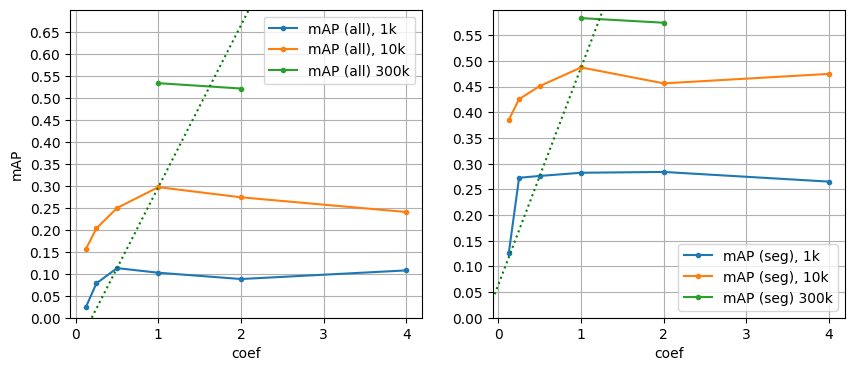

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
metric = 'mAP (all)'
tbl1[metric].plot(marker='.', label='mAP (all), 1k')
tbl2[metric].plot(marker='.', label='mAP (all), 10k')
big[metric].plot(marker='.', label='mAP (all) 300k')
plt.axline([0.5, tbl1.loc[0.5][metric]], [1,tbl2.loc[1][metric]], color='g', linestyle=':')

plt.xlabel('coef')
plt.ylabel('mAP')
plt.legend()
plt.grid()
plt.ylim([0, 0.70])
plt.yticks([0.05*i for i in range(0, 14)])

plt.subplot(1, 2, 2)
metric= 'mAP (seg)'
tbl1[metric].plot(marker='.', label='mAP (seg), 1k')
tbl2[metric].plot(marker='.', label='mAP (seg), 10k')
big[metric].plot(marker='.', label='mAP (seg) 300k')
plt.axline([0.5, tbl1.loc[0.5][metric]], [1,tbl2.loc[1][metric]], color='g', linestyle=':')
plt.xlabel('coef')

plt.legend()
plt.grid()
plt.ylim([0, 0.60])
plt.yticks([0.05*i for i in range(0, 12)])

In [29]:
	mAP (all)	mAP (seg)
1	0.5276715159416199	0.5747573375701904
mAP (all)": 0.5629443526268005, "mAP (seg)": 0.5975230932235718

np.float64(0.2761916518211365)

In [53]:
big = []

with open('../big_model/result_epoch_coef_1_20260528/row2region_GLAM_start_no_0_tmp_9_res.txt', 'r') as f:
    res = json.load(f)
    big.append({'coef': 1, "mAP (all)": res['mAP (all)'], "mAP (seg)": res['mAP (seg)']})


with open('../big_model/result_epoch_coef_2_20260530/row2region_GLAM_start_no_0_tmp_9_res.txt', 'r') as f:
    res = json.load(f)
    big.append({'coef': 2, "mAP (all)": res['mAP (all)'], "mAP (seg)": res['mAP (seg)']})
big = pd.DataFrame(big)
big = big.set_index('coef')

In [55]:
big

,mAP (all),mAP (seg)
coef,,
1,0.533079,0.583643
2,0.520911,0.574659
